# NB09 — Clasificación M2: RF Tuneado + XGBoost
**ZMM Movilidad Predictiva**

**Objetivo:** Clasificar nivel de riesgo vial (bajo/medio/alto) sin overfitting.

**Mejoras vs versión anterior:**
- Hiperparámetros limitados (max_depth, min_samples)
- NaN espaciales: flag binario + mediana (no fillna(0))
- Features nuevas: tipo_dia, nivel_impacto, cluster_hora (M1)
- Comparación RF vs XGBoost
- Validación temporal (train 2023-2024, test 2025)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

RUTA_PROCESSED = '../data_processed/'
RUTA_OUTPUTS   = '../outputs/'

print('='*65)
print('NB09: CLASIFICACION M2 — RF TUNEADO + XGBOOST')
print('='*65)

NB09: CLASIFICACION M2 — RF TUNEADO + XGBOOST


## 1. Carga y Target

In [2]:
df = pd.read_csv(RUTA_PROCESSED + 'super_tabla_con_clusters.csv', parse_dates=['fecha_hora'])
df = df[(df['fecha_hora'] >= '2023-01-01') & (df['fecha_hora'] <= '2025-12-31 23:00:00')].copy()
print(f'Shape: {df.shape}')

# Target: cut fijo (evita desbalance de qcut con empates enteros)
df['nivel_riesgo'] = pd.cut(
    df['siniestros_zona_industrial'],
    bins=[-1, 2, 5, 100], labels=[0, 1, 2]
).astype(int)

distrib = df['nivel_riesgo'].value_counts().sort_index()
print(f'\nTarget:')
for nivel, count in distrib.items():
    label = ['BAJO (0-2)', 'MEDIO (3-5)', 'ALTO (6+)'][nivel]
    print(f'  {label}: {count:,} ({count/len(df)*100:.1f}%)')

Shape: (26304, 30)

Target:
  BAJO (0-2): 11,757 (44.7%)
  MEDIO (3-5): 8,920 (33.9%)
  ALTO (6+): 5,627 (21.4%)


## 2. Features (sin leakage, NaN correctos)

In [3]:
# NaN espaciales: flag binario + mediana
spatial_feats = ['dist_industrial_promedio', 'dist_industrial_minima',
                 'siniestros_en_zona', 'masa_laboral_max']
df['tiene_dato_espacial'] = df[spatial_feats[0]].notna().astype(int)
for sf in spatial_feats:
    df[sf] = df[sf].fillna(df[sf].median())

# One-hot tipo_dia
if 'tipo_dia' in df.columns:
    td = pd.get_dummies(df['tipo_dia'], prefix='td', drop_first=True)
    df = pd.concat([df, td], axis=1)
    tipo_dia_cols = td.columns.tolist()
else:
    tipo_dia_cols = []

features_modelo = [
    'hora_del_dia', 'dia_semana', 'es_fin_de_semana', 'intensidad_hora_pico',
    'temperatura_c', 'nivel_lluvia',
    'impacto_evento_activo', 'asistencia_estimada',
    'dist_industrial_promedio', 'dist_industrial_minima',
    'siniestros_en_zona', 'masa_laboral_max',
    'tiene_dato_espacial', 'cluster_hora',
] + tipo_dia_cols
if 'nivel_impacto' in df.columns:
    features_modelo.append('nivel_impacto')
features_modelo = [f for f in features_modelo if f in df.columns]

X = df[features_modelo].copy()
y = df['nivel_riesgo']
print(f'Features ({len(features_modelo)}): {features_modelo}')
print(f'Nulos: {X.isnull().sum().sum()}')

Features (17): ['hora_del_dia', 'dia_semana', 'es_fin_de_semana', 'intensidad_hora_pico', 'temperatura_c', 'nivel_lluvia', 'impacto_evento_activo', 'asistencia_estimada', 'dist_industrial_promedio', 'dist_industrial_minima', 'siniestros_en_zona', 'masa_laboral_max', 'tiene_dato_espacial', 'cluster_hora', 'td_laboral_industrial', 'td_laboral_mixto', 'nivel_impacto']
Nulos: 0


## 3. Split + Entrenamiento

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# RF tuneado
print('\n--- Random Forest (tuneado) ---')
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42,
    n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
rf_f1 = f1_score(y_test, rf.predict(X_test), average='macro')
rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_gap = accuracy_score(y_train, rf.predict(X_train)) - rf_acc
print(f'  Acc test={rf_acc:.4f} | F1m test={rf_f1:.4f} | Gap={rf_gap:.4f}')

# XGBoost
print('\n--- XGBoost ---')
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    n_jobs=-1, eval_metric='mlogloss', early_stopping_rounds=30)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_f1 = f1_score(y_test, xgb_model.predict(X_test), average='macro')
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))
xgb_gap = accuracy_score(y_train, xgb_model.predict(X_train)) - xgb_acc
print(f'  Acc test={xgb_acc:.4f} | F1m test={xgb_f1:.4f} | Gap={xgb_gap:.4f}')

# Ganador
if xgb_f1 > rf_f1:
    ganador, ganador_m, ganador_f1, ganador_acc = 'XGBoost', xgb_model, xgb_f1, xgb_acc
else:
    ganador, ganador_m, ganador_f1, ganador_acc = 'RF Tuneado', rf, rf_f1, rf_acc
print(f'\nGANADOR: {ganador} (F1m={ganador_f1:.4f})')

Train: 21,043 | Test: 5,261

--- Random Forest (tuneado) ---
  Acc test=0.6767 | F1m test=0.6586 | Gap=0.1227

--- XGBoost ---
  Acc test=0.6951 | F1m test=0.6695 | Gap=0.0780

GANADOR: XGBoost (F1m=0.6695)


## 4. Validación Temporal

In [5]:
df_tt = df[df['fecha_hora'].dt.year.isin([2023,2024])]
df_tv = df[df['fecha_hora'].dt.year == 2025]

if ganador == 'XGBoost':
    tm = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, eval_metric='mlogloss', early_stopping_rounds=30)
    tm.fit(df_tt[features_modelo], df_tt['nivel_riesgo'],
           eval_set=[(df_tv[features_modelo], df_tv['nivel_riesgo'])], verbose=False)
else:
    tm = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
        min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1, class_weight='balanced')
    tm.fit(df_tt[features_modelo], df_tt['nivel_riesgo'])

temp_f1 = f1_score(df_tv['nivel_riesgo'], tm.predict(df_tv[features_modelo]), average='macro')
temp_acc = accuracy_score(df_tv['nivel_riesgo'], tm.predict(df_tv[features_modelo]))
print(f'Temporal: Acc={temp_acc:.4f} | F1m={temp_f1:.4f}')
print(f'Degradacion: {ganador_f1 - temp_f1:.4f} puntos F1')

Temporal: Acc=0.6533 | F1m=0.5919
Degradacion: 0.0776 puntos F1


## 5. Classification Report + Visualizaciones

              precision    recall  f1-score   support

  Bajo (0-2)       0.80      0.83      0.81      2352
 Medio (3-5)       0.57      0.62      0.59      1784
   Alto (6+)       0.69      0.54      0.60      1125

    accuracy                           0.70      5261
   macro avg       0.68      0.66      0.67      5261
weighted avg       0.70      0.70      0.69      5261



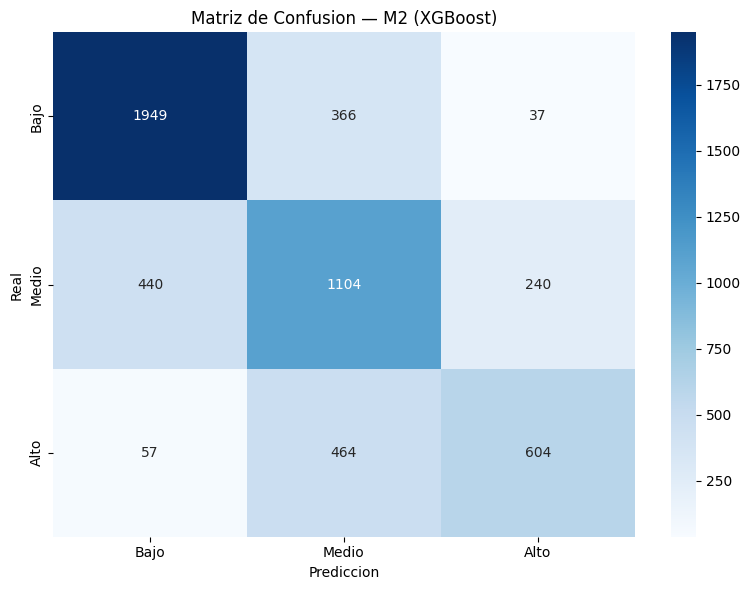

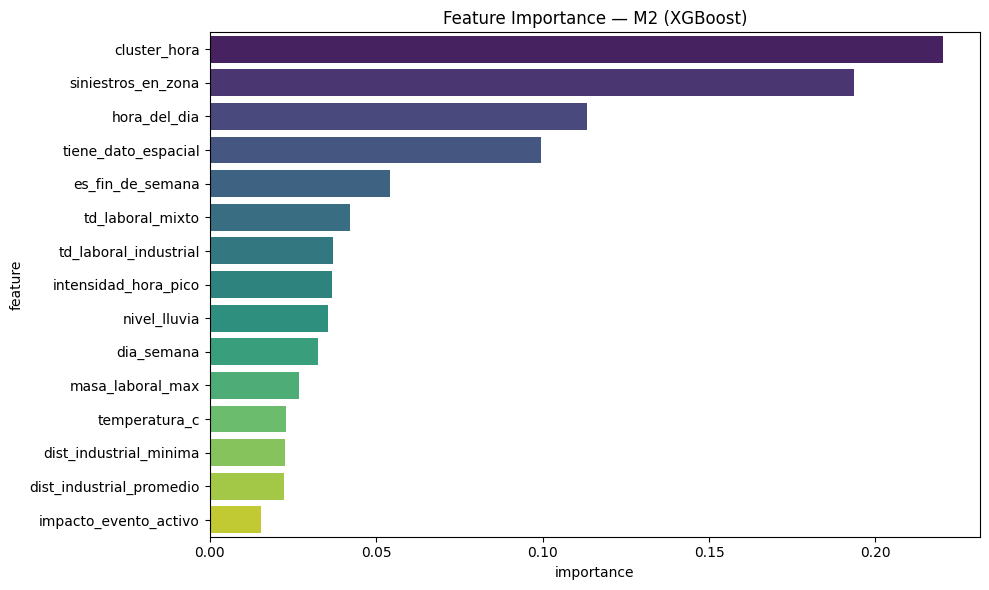

In [6]:
pred = ganador_m.predict(X_test)
print(classification_report(y_test, pred,
      target_names=['Bajo (0-2)', 'Medio (3-5)', 'Alto (6+)']))

# Confusion matrix
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Bajo','Medio','Alto'], yticklabels=['Bajo','Medio','Alto'])
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusion — M2 ({ganador})')
plt.tight_layout()
plt.savefig(RUTA_OUTPUTS + 'm2_matriz_confusion.png', dpi=150)
plt.show()

# Feature importance
imp_df = pd.DataFrame({'feature': features_modelo,
    'importance': ganador_m.feature_importances_}).sort_values('importance', ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=imp_df.head(15), y='feature', x='importance', palette='viridis', ax=ax)
ax.set_title(f'Feature Importance — M2 ({ganador})')
plt.tight_layout()
plt.savefig(RUTA_OUTPUTS + 'm2_feature_importance.png', dpi=150)
plt.show()

In [7]:
# Guardar modelo
modelo_data = {
    'modelo': ganador_m, 'nombre': ganador, 'features': features_modelo,
    'target': 'nivel_riesgo', 'target_bins': '0-2=bajo, 3-5=medio, 6+=alto',
    'accuracy_test': ganador_acc, 'f1_macro_test': ganador_f1,
    'confusion_matrix': cm, 'feature_importance': imp_df, 'temporal_f1': temp_f1,
}
with open(RUTA_OUTPUTS + 'modelo_m2_rf.pkl', 'wb') as f:
    pickle.dump(modelo_data, f)

print(f'Modelo guardado: modelo_m2_rf.pkl ({ganador})')
print(f'F1 macro test: {ganador_f1:.4f} | F1 temporal: {temp_f1:.4f}')

Modelo guardado: modelo_m2_rf.pkl (XGBoost)
F1 macro test: 0.6695 | F1 temporal: 0.5919
